In [1]:
# IMPORTING THE NECESSARY LIBRARIES

import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.nn.modules.dropout import Dropout
from torchvision import datasets, transforms

In [2]:
img = cv2.imread('/kaggle/input/datasets/fizzazaitoonbsds2022/2d-ct-kidney-for-classification/split_data/train/Normal/Normal- (1).jpg')

print(img.shape)

(512, 512, 3)


In [3]:
# SETTING UP TRANSFORMATIONS FOR THE TRAINING AND VALIDATION SETS

train_transform = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),   
    transforms.RandomRotation(degrees=20),  
    transforms.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.92, 1.08)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [4]:
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [5]:
train_dataset = datasets.ImageFolder("/kaggle/input/datasets/fizzazaitoonbsds2022/2d-ct-kidney-for-classification/split_data/train", transform=train_transform)
val_dataset = datasets.ImageFolder("/kaggle/input/datasets/fizzazaitoonbsds2022/2d-ct-kidney-for-classification/split_data/val", transform=val_transform)

In [6]:
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, pin_memory=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, pin_memory=True, num_workers=4)

In [7]:
images, labels = next(iter(train_loader))

print(images.shape)

torch.Size([128, 3, 224, 224])


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
print(device)

cuda


In [10]:
print(torch.cuda.device_count())

2


In [11]:
# SETTING THE MODEL AND ITS CUSTOM FC ARCHITECTURE

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

in_features = model.fc.in_features

model.fc = nn.Sequential(

    nn.Linear(in_features, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    
    nn.Linear(128, 4)
    
)

if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)

model = model.to(device)

In [12]:
# FREEZING ALL LAYERS
for param in model.parameters():
    param.requires_grad = False
    
# UNFREEZING THE CLASSIFIER HEAD
for param in model.module.fc.parameters():
    param.requires_grad = True

In [13]:
# SETTING UP LOSS AND OPTIMIZER

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.module.fc.parameters(), lr=0.005, weight_decay=1e-2)

In [ ]:
# WARM-UP TRAINING OF THE CLASSIFIER HEAD (FC HEAD) ONLY

epochs_stage_1 = 5

for epoch in range(epochs_stage_1):

  # TRAINING
  model.train()
  train_loss = 0
  train_correct = 0  
  train_total = 0    

  for batch_features, batch_labels in train_loader:

    batch_features = batch_features.to(device)
    batch_labels = batch_labels.to(device)

    optimizer.zero_grad()
    y_pred = model(batch_features)
    loss = criterion(y_pred, batch_labels)

    loss.backward()
    optimizer.step()

    train_loss += loss.item()

    _, train_predicted = torch.max(y_pred, 1)
    train_total += batch_labels.size(0)
    train_correct += (train_predicted == batch_labels).sum().item()

  train_loss /= len(train_loader)
  train_acc = train_correct / train_total 

  # VALIDATION
  model.eval()
  val_loss = 0
  correct = 0
  total = 0

  with torch.no_grad():
    for batch_features, batch_labels in val_loader:

      batch_features = batch_features.to(device)
      batch_labels = batch_labels.to(device)

      outputs = model(batch_features)
      loss = criterion(outputs, batch_labels)

      val_loss += loss.item()

      _, predicted = torch.max(outputs, 1)
      total += batch_labels.size(0)
      correct += (predicted == batch_labels).sum().item()

  val_loss /= len(val_loader)
  val_acc = correct / total

  # PRINTING THE RESULTS
  print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

In [14]:
# UNFREEZING THE LAYER4 OF RESNET

for param in model.module.layer4.parameters():
    param.requires_grad = True

In [15]:
# SETTING OPTIMIZER AGAIN BUT FOR BOTH: LAYER4 AND FC HEAD

optimizer = torch.optim.AdamW([
    {'params': model.module.layer4.parameters(), 'lr': 0.005, 'weight_decay': 1e-2},
    {'params': model.module.fc.parameters(), 'lr': 0.005, 'weight_decay': 1e-2}
])

In [16]:
# SETTING UP THE SCHEDULER

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.2, patience=2, cooldown=2)

In [ ]:
# TRAINING THE MODEL NOW ON BOTH LAYERS: LAYER4 AND FC HEAD

epochs_stage_2 = 20

best_val_loss = float('inf')  

for epoch in range(epochs_stage_2):

  # TRAINING
  model.train()
  train_loss = 0
  train_correct = 0  
  train_total = 0    

  for batch_features, batch_labels in train_loader:

    batch_features = batch_features.to(device)
    batch_labels = batch_labels.to(device)

    optimizer.zero_grad()
    y_pred = model(batch_features)
    loss = criterion(y_pred, batch_labels)

    loss.backward()
    optimizer.step()

    train_loss += loss.item()

    _, train_predicted = torch.max(y_pred, 1)
    train_total += batch_labels.size(0)
    train_correct += (train_predicted == batch_labels).sum().item()

  train_loss /= len(train_loader)
  train_acc = train_correct / train_total  

  # VALIDATION
  model.eval()
  val_loss = 0
  correct = 0
  total = 0

  with torch.no_grad():
    for batch_features, batch_labels in val_loader:

      batch_features = batch_features.to(device)
      batch_labels = batch_labels.to(device)

      outputs = model(batch_features)
      loss = criterion(outputs, batch_labels)

      val_loss += loss.item()

      _, predicted = torch.max(outputs, 1)
      total += batch_labels.size(0)
      correct += (predicted == batch_labels).sum().item()

  val_loss /= len(val_loader)
  val_acc = correct / total

  # PRINTING THE RESULTS
  print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

  scheduler.step(val_loss)
    
  # CHECKPOINT TO SAVE THE BEST MODEL
  if val_loss < best_val_loss:
    print(f"Validation loss improved ({best_val_loss:.4f} → {val_loss:.4f}). Saving model...")

    torch.save({
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'train_loss': train_loss,
        'val_loss': val_loss,
        'val_acc': val_acc
    }, "best_checkpoint.pth")

    best_val_loss = val_loss

In [17]:
# LOADING THE BEST MODEL...

checkpoint = torch.load("/kaggle/input/datasets/mubeenakhund/best-checkpoint-params/best_checkpoint.pth", map_location=device)

model.load_state_dict(checkpoint['model_state'])

<All keys matched successfully>

In [ ]:
model

In [18]:
# SETTING UP TRANSFORMATIONS AND LOADER CLASSES FOR THE TEST SET

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_dataset = datasets.ImageFolder("/kaggle/input/datasets/fizzazaitoonbsds2022/2d-ct-kidney-for-classification/split_data/test", transform=test_transform)

test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, pin_memory=True, num_workers=4)

In [19]:
model = model.to(device)
model.eval()

# MODEL EVALUATION ON TEST SET
test_loss = 0
correct = 0
total = 0

with torch.no_grad():
    for batch_features, batch_labels in test_loader:

        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        outputs = model(batch_features)
        loss = criterion(outputs, batch_labels)

        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += batch_labels.size(0)
        correct += (predicted == batch_labels).sum().item()


test_loss /= len(test_loader)
test_acc = correct / total

print("\n===== FINAL TEST RESULTS =====")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


===== FINAL TEST RESULTS =====
Test Loss: 0.1633
Test Accuracy: 0.9405


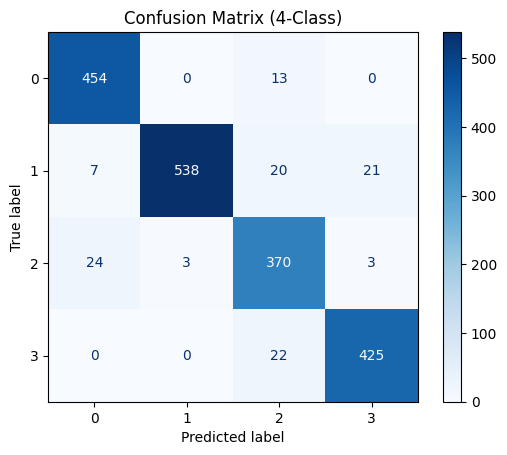

In [20]:
# CREATING CONFUSION MATRIX FOR DISPLAYING CLASS-WISE PREDICTION ERRORS AND CORRECT PREDICTIONS

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        # MOVING GPU TESNORS TO CPU AND CONVERTING THEM TO NUMPY ARRAYS FOR BETTER USAGE IN SKLEARN EVAL FUNCTIONS
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix (4-Class)")
plt.show()

In [21]:
# Generating precision, recall, F1-score, and support for each class

from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    digits=4
))

              precision    recall  f1-score   support

           0     0.9361    0.9722    0.9538       467
           1     0.9945    0.9181    0.9547       586
           2     0.8706    0.9250    0.8970       400
           3     0.9465    0.9508    0.9487       447

    accuracy                         0.9405      1900
   macro avg     0.9369    0.9415    0.9385      1900
weighted avg     0.9428    0.9405    0.9409      1900



In [ ]:
!pip install grad-cam

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# 1. Targetting the final convolutional layer of our network
target_layers = [model.module.layer4[-1]] 

# 2. Initializing the GradCAM object from the library
cam = GradCAM(model=model, target_layers=target_layers)

# 3. Getting a sample batch from the test loader
images, labels = next(iter(test_loader))

# Taking the very first image from the batch and moving it to the device
img_tensor = images[0].unsqueeze(0).to(device)  
true_label = labels[0].item()

# 4. Telling the library to track the target class
targets = [ClassifierOutputTarget(true_label)]

# 5. Generating the heatmap mask
grayscale_mask = cam(input_tensor=img_tensor, targets=targets)[0]  

# 6. Converting the original PyTorch tensor back to a normal RGB NumPy image
# Rearranges shape from [3, 224, 224] to [224, 224, 3]
rgb_img = images[0].permute(1, 2, 0).cpu().numpy()

# 7. Reversing the training normalization so the image colors look crisp and clear
rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())

# 8. Superimposing the grayscale heatmap onto the actual RGB image
color_heatmap_overlay = show_cam_on_image(rgb_img, grayscale_mask, use_rgb=True)

# 9. Plotting the result side-by-side with the original image
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

try:
    class_names = test_loader.dataset.classes
    class_name_str = class_names[true_label]
except AttributeError:
    class_map = {0: "Cyst", 1: "Normal", 2: "Stone", 3: "Tumor"}
    class_name_str = class_map.get(true_label, f"Class {true_label}")

ax[0].imshow(rgb_img)
ax[0].set_title(f"Original CT Scan ({class_name_str})")
ax[0].axis('off')

ax[1].imshow(color_heatmap_overlay)
ax[1].set_title(f"Grad-CAM Model Attention")
ax[1].axis('off')

plt.tight_layout()
plt.show()

****THANKS!***